# EDA датасетов CUAD и ContractNLI

Цель ноутбука — воспроизводимо провести разведочный анализ данных для проекта **Агент «Договорный инспектор»**.

Ноутбук можно запускать через **Run All**: все переменные создаются в правильном порядке, скрытых зависимостей от предыдущих запусков нет.

Результаты сохраняются в:

- `data/processed/eda/` — таблицы CSV/JSONL;
- `reports/eda/figures/` — графики;

In [ ]:
from __future__ import annotations

import ast
import json
import math
import re
from pathlib import Path
from typing import Any

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd

from contract_inspector.settings.paths import DATA_DIR
from contract_inspector.data.text import (
    CONTROL_CHARS_RE, SPACES_RE,
    NEWLINES_RE, WORD_RE,
    ANSWER_COLUMN_RE, EMPTY_STRINGS,
    normalize_text, count_words,
    approx_tokens_en, is_non_empty,
    read_json, read_text_file
)
from contract_inspector.data.document_parse import (
    normalize_doc_key, contractnli_label_text,
    contractnli_label_short_description, normalize_contractnli_choice,
    normalize_span, build_contractnli_span_lookup,
    extract_evidence_from_annotation, extract_annotation_choice,
    iter_contractnli_annotations, flatten_contractnli_split
)

In [31]:
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
EDA_DIR = PROCESSED_DIR / "eda"
REPORTS_DIR = DATA_DIR.parent / "reports" / "eda"
FIGURES_DIR = REPORTS_DIR / "figures"

EDA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("EDA_DIR:", EDA_DIR)
print("REPORTS_DIR:", REPORTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

DATA_DIR: /data/source/personal/awesome-ai-engineer/project/data
RAW_DIR: /data/source/personal/awesome-ai-engineer/project/data/raw
PROCESSED_DIR: /data/source/personal/awesome-ai-engineer/project/data/processed
EDA_DIR: /data/source/personal/awesome-ai-engineer/project/data/processed/eda
REPORTS_DIR: /data/source/personal/awesome-ai-engineer/project/reports/eda
FIGURES_DIR: /data/source/personal/awesome-ai-engineer/project/reports/eda/figures


## Поиск файлов датасетов

In [32]:
def find_one(base: Path, pattern: str) -> Path:
    matches = sorted(base.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"Не найден путь по шаблону: {base / pattern}")
    if len(matches) > 1:
        print(f"Найдено несколько путей для {pattern}:")
        for item in matches[:10]:
            print(" ", item)
        print("Использую первый:", matches[0])
    return matches[0]


CUAD_MASTER_PATH = find_one(RAW_DIR / "cuad", "**/master_clauses.csv")
CUAD_JSON_PATH = find_one(RAW_DIR / "cuad", "**/CUAD_v1.json")
CUAD_TXT_DIR = find_one(RAW_DIR / "cuad", "**/full_contract_txt")

CONTRACT_NLI_TRAIN_PATH = find_one(RAW_DIR / "contractnli", "**/train.json")
CONTRACT_NLI_DEV_PATH = find_one(RAW_DIR / "contractnli", "**/dev.json")
CONTRACT_NLI_TEST_PATH = find_one(RAW_DIR / "contractnli", "**/test.json")

print("CUAD_MASTER_PATH:", CUAD_MASTER_PATH)
print("CUAD_JSON_PATH:", CUAD_JSON_PATH)
print("CUAD_TXT_DIR:", CUAD_TXT_DIR)
print("CONTRACT_NLI_TRAIN_PATH:", CONTRACT_NLI_TRAIN_PATH)
print("CONTRACT_NLI_DEV_PATH:", CONTRACT_NLI_DEV_PATH)
print("CONTRACT_NLI_TEST_PATH:", CONTRACT_NLI_TEST_PATH)

CUAD_MASTER_PATH: /data/source/personal/awesome-ai-engineer/project/data/raw/cuad/CUAD_v1/CUAD_v1/master_clauses.csv
CUAD_JSON_PATH: /data/source/personal/awesome-ai-engineer/project/data/raw/cuad/CUAD_v1/CUAD_v1/CUAD_v1.json
CUAD_TXT_DIR: /data/source/personal/awesome-ai-engineer/project/data/raw/cuad/CUAD_v1/CUAD_v1/full_contract_txt
CONTRACT_NLI_TRAIN_PATH: /data/source/personal/awesome-ai-engineer/project/data/raw/contractnli/contract-nli/contract-nli/train.json
CONTRACT_NLI_DEV_PATH: /data/source/personal/awesome-ai-engineer/project/data/raw/contractnli/contract-nli/contract-nli/dev.json
CONTRACT_NLI_TEST_PATH: /data/source/personal/awesome-ai-engineer/project/data/raw/contractnli/contract-nli/contract-nli/test.json


## Общие функции

In [ ]:
def save_hist(series: pd.Series, title: str, xlabel: str, output_path: Path, bins: int = 50) -> None:
    plt.figure(figsize=(10, 6))
    plt.hist(series.dropna(), bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()


def save_bar(frame: pd.DataFrame, x_col: str, y_col: str, title: str, xlabel: str, ylabel: str, output_path: Path) -> None:
    plt.figure(figsize=(14, 8))
    plt.bar(frame[x_col].astype(str), frame[y_col])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=80, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()



## Загрузка CUAD

In [34]:
cuad_master = pd.read_csv(CUAD_MASTER_PATH)

print("CUAD master shape:", cuad_master.shape)
display(cuad_master.head())
display(pd.DataFrame({"column": cuad_master.columns}))

CUAD master shape: (510, 83)


,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of ...,NaN,['This agreement shall begin upon the date of ...,...,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR T...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']",7/11/06,"['July 11 , 2006']",7/11/06,"['The term of this Agreement (the ""Initial Ter...",...,[],No,[],No,[],No,[],No,[],No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,['CONTENT DISTRIBUTION AND LICENSE AGREEMENT'],CONTENT DISTRIBUTION AND LICENSE AGREEMENT,"['Producer', 'Fulucai Productions Ltd.', 'Conv...","CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","['November 15, 2012']",11/15/12,"['November 15, 2012']",11/15/12,[],...,[],No,[],No,[],No,[],No,[],No
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...,['WEBSITE CONTENT LICENSE AGREEMENT'],WEBSITE CONTENT LICENSE AGREEMENT,"['PSiTech Corporation', 'Licensor', 'Licensee'...","PSiTech Corporation (""Licensor""); Empirical Ve...","['Feb 10, 2014']",2/10/14,"['Feb 10, 2014']",2/10/14,['The initial term of this Agreement commences...,...,[],No,[],No,[],No,[],No,[],No
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...,['CONTENT LICENSE AGREEMENT'],CONTENT LICENSE AGREEMENT,"['YOU ON DEMAND HOLDINGS, INC.', 'Licensor', '...",Beijing Sun Seven Stars Culture Development Li...,"['December 21, 2015']",12/21/15,"['December 21, 2015']",12/21/15,"['The Term of this Agreement (the ""Term"") shal...",...,[],No,[],No,[],No,[],No,[],No


,column
0,Filename
1,Document Name
2,Document Name-Answer
3,Parties
4,Parties-Answer
...,...
78,Insurance-Answer
79,Covenant Not To Sue
80,Covenant Not To Sue-Answer
81,Third Party Beneficiary


In [35]:
DOCUMENT_COLUMN_CANDIDATES = [
    "Filename",
    "File Name",
    "file_name",
    "filename",
    "Document",
    "Document Name",
]

document_col = next(
    (col for col in DOCUMENT_COLUMN_CANDIDATES if col in cuad_master.columns),
    None,
)

print("document_col:", document_col)

cuad_column_stats = []

for col in cuad_master.columns:
    non_empty_count = int(cuad_master[col].map(is_non_empty).sum())
    empty_count = int(len(cuad_master) - non_empty_count)

    examples = (
        cuad_master.loc[cuad_master[col].map(is_non_empty), col]
        .astype(str)
        .head(3)
        .tolist()
    )

    cuad_column_stats.append(
        {
            "column": col,
            "non_empty_count": non_empty_count,
            "empty_count": empty_count,
            "non_empty_share": non_empty_count / len(cuad_master) if len(cuad_master) else 0,
            "example_values": examples,
        }
    )

cuad_column_stats = pd.DataFrame(cuad_column_stats)
cuad_column_stats = cuad_column_stats.sort_values(
    ["non_empty_count", "column"],
    ascending=[False, True],
)

display(cuad_column_stats.head(30))
cuad_column_stats.to_csv(EDA_DIR / "cuad_column_stats.csv", index=False)

document_col: Filename


,column,non_empty_count,empty_count,non_empty_share,example_values
58,Affiliate License-Licensee-Answer,510,0,1.0,"[No, No, Yes]"
56,Affiliate License-Licensor-Answer,510,0,1.0,"[No, No, No]"
38,Anti-Assignment-Answer,510,0,1.0,"[Yes, Yes, No]"
68,Audit Rights-Answer,510,0,1.0,"[Yes, Yes, Yes]"
72,Cap On Liability-Answer,510,0,1.0,"[Yes, Yes, No]"
36,Change Of Control-Answer,510,0,1.0,"[No, No, No]"
20,Competitive Restriction Exception-Answer,510,0,1.0,"[No, No, No]"
80,Covenant Not To Sue-Answer,510,0,1.0,"[No, No, No]"
1,Document Name,510,0,1.0,"[['MARKETING AFFILIATE AGREEMENT'], ['VIDEO-ON..."
2,Document Name-Answer,510,0,1.0,"[MARKETING AFFILIATE AGREEMENT, VIDEO-ON-DEMAN..."


In [36]:
cuad_txt_paths = sorted(CUAD_TXT_DIR.glob("*.txt"))

cuad_docs = []

for path in cuad_txt_paths:
    raw_text = read_text_file(path)
    normalized = normalize_text(raw_text)

    cuad_docs.append(
        {
            "dataset": "cuad",
            "file_name": path.name,
            "file_stem": path.stem,
            "path": str(path),
            "chars": len(normalized),
            "words": count_words(normalized),
            "approx_tokens": approx_tokens_en(normalized),
            "lines": normalized.count("\n") + 1 if normalized else 0,
            "empty": not bool(normalized),
        }
    )

cuad_docs = pd.DataFrame(cuad_docs)

print("CUAD txt files:", len(cuad_docs))
display(cuad_docs.head())
display(cuad_docs[["chars", "words", "approx_tokens", "lines"]].describe())

cuad_docs.to_csv(EDA_DIR / "cuad_documents.csv", index=False)

CUAD txt files: 510


,dataset,file_name,file_stem,path,chars,words,approx_tokens,lines,empty
0,cuad,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,/data/source/personal/awesome-ai-engineer/proj...,28862,4466,7216,195,False
1,cuad,ABILITYINC_06_15_2020-EX-4.25-SERVICES AGREEME...,ABILITYINC_06_15_2020-EX-4.25-SERVICES AGREEMENT,/data/source/personal/awesome-ai-engineer/proj...,26306,4078,6577,39,False
2,cuad,ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-...,ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-...,/data/source/personal/awesome-ai-engineer/proj...,11969,1909,2993,79,False
3,cuad,ACCURAYINC_09_01_2010-EX-10.31-DISTRIBUTOR AGR...,ACCURAYINC_09_01_2010-EX-10.31-DISTRIBUTOR AGR...,/data/source/personal/awesome-ai-engineer/proj...,86849,13194,21713,125,False
4,cuad,ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT A...,ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT A...,/data/source/personal/awesome-ai-engineer/proj...,24353,3684,6089,255,False


,chars,words,approx_tokens,lines
count,510.000000,510.000000,510.000000,510.000000
mean,50632.174510,7785.403922,12658.407843,290.917647
std,53947.294199,8235.304226,13486.809185,409.131628
min,645.000000,109.000000,162.000000,1.000000
25%,16149.500000,2436.750000,4038.000000,59.000000
50%,32141.500000,4971.000000,8036.000000,144.000000
75%,65339.250000,10066.750000,16335.000000,353.500000
max,300304.000000,47642.000000,75076.000000,4027.000000


In [ ]:
if document_col is not None:
    master_keys = set(cuad_master[document_col].dropna().map(normalize_doc_key))
    txt_keys = set(cuad_docs["file_stem"].map(normalize_doc_key))

    matched = master_keys & txt_keys
    only_master = master_keys - txt_keys
    only_txt = txt_keys - master_keys

    print("CUAD master docs:", len(master_keys))
    print("CUAD txt docs:", len(txt_keys))
    print("Matched:", len(matched))
    print("Only in master:", len(only_master))
    print("Only in txt:", len(only_txt))

    display(pd.DataFrame({"only_master_sample": sorted(only_master)[:20]}))
    display(pd.DataFrame({"only_txt_sample": sorted(only_txt)[:20]}))
else:
    print("Не нашёл колонку с именем документа в master_clauses.csv. Это критично для CUAD evidence matching.")


CUAD master docs: 510
CUAD txt docs: 510
Matched: 496
Only in master: 14
Only in txt: 14


,only_master_sample
0,"adma biomanufacturing, llc - amendment #3 to m..."
1,electrameccanica vehicles corp. - manufacturin...
2,kalloinc_11_03_2011-ex-10.1-strategic alliance...
3,leclanché s.a. - joint development and market...
4,"macy's,inc_05_11_2020-ex-99.4-joint filing agr..."
5,moelis&co_03_24_2014-ex-10.19-strategic allian...
6,monsanto company - second a&r exclusive agency...
7,"netgear,inc_04_21_2003-ex-10.16-amendment to t..."
8,"pacira pharmaceuticals, inc. - a&r strategic l..."
9,playahotels&resortsnv_03_14_2017-ex-10.22-stra...


,only_txt_sample
0,"adma biomanufacturing, llc - amendment #3 to m..."
1,electrameccanica vehicles corp. - manufacturin...
2,kalloinc_11_03_2011-ex-10.1-strategic alliance...
3,leclanché s.a. - joint development and marketi...
4,"macy_s,inc_05_11_2020-ex-99.4-joint filing agr..."
5,moelis_co_03_24_2014-ex-10.19-strategic allian...
6,monsanto company - second a_r exclusive agency...
7,"netgear,inc_04_21_2003-ex-10.16-amendment to t..."
8,"pacira pharmaceuticals, inc. - a_r strategic l..."
9,playahotels_resortsnv_03_14_2017-ex-10.22-stra...


## Загрузка и парсинг ContractNLI

In [38]:
contractnli_raw = {
    "train": read_json(CONTRACT_NLI_TRAIN_PATH),
    "dev": read_json(CONTRACT_NLI_DEV_PATH),
    "test": read_json(CONTRACT_NLI_TEST_PATH),
}

for split, payload in contractnli_raw.items():
    print("\nSPLIT:", split)
    print("top-level keys:", payload.keys())

    documents = payload.get("documents", [])
    labels = payload.get("labels", {})

    print("documents type:", type(documents))
    print("documents:", len(documents))
    print("labels type:", type(labels))
    print("labels:", len(labels))

    if documents:
        first_doc = documents[0]
        print("first_doc id:", first_doc.get("id"))
        print("first_doc keys:", first_doc.keys())

    if labels:
        first_label_id = next(iter(labels))
        print("first_label_id:", first_label_id)
        print("first_label:", labels[first_label_id])


SPLIT: train
top-level keys: dict_keys(['documents', 'labels'])
documents type: <class 'list'>
documents: 423
labels type: <class 'dict'>
labels: 17
first_doc id: 34
first_doc keys: dict_keys(['id', 'file_name', 'text', 'spans', 'annotation_sets', 'document_type', 'url'])
first_label_id: nda-11
first_label: {'short_description': 'No reverse engineering', 'hypothesis': "Receiving Party shall not reverse engineer any objects which embody Disclosing Party's Confidential Information."}

SPLIT: dev
top-level keys: dict_keys(['documents', 'labels'])
documents type: <class 'list'>
documents: 61
labels type: <class 'dict'>
labels: 17
first_doc id: 3
first_doc keys: dict_keys(['id', 'file_name', 'text', 'spans', 'annotation_sets', 'document_type', 'url'])
first_label_id: nda-11
first_label: {'short_description': 'No reverse engineering', 'hypothesis': "Receiving Party shall not reverse engineer any objects which embody Disclosing Party's Confidential Information."}

SPLIT: test
top-level keys:

In [40]:
contractnli_doc_frames = []
contractnli_example_frames = []

for split, payload in contractnli_raw.items():
    docs_frame, examples_frame = flatten_contractnli_split(split, payload)
    contractnli_doc_frames.append(docs_frame)
    contractnli_example_frames.append(examples_frame)

contractnli_docs = pd.concat(contractnli_doc_frames, ignore_index=True)
contractnli_examples = pd.concat(contractnli_example_frames, ignore_index=True)

print("ContractNLI docs:", contractnli_docs.shape)
print("ContractNLI examples:", contractnli_examples.shape)

display(contractnli_docs.head())
display(contractnli_examples.head())

contractnli_docs.to_csv(EDA_DIR / "contractnli_documents.csv", index=False)

contractnli_examples.drop(columns=["evidence"], errors="ignore").to_csv(
    EDA_DIR / "contractnli_examples.csv",
    index=False,
)

contractnli_examples.to_json(
    EDA_DIR / "contractnli_examples_with_evidence.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

ContractNLI docs: (607, 13)
ContractNLI examples: (10319, 15)


,dataset,split,doc_id,file_name,document_type,url,chars,words,approx_tokens,spans_count,annotation_sets_count,annotations_count,empty
0,contractnli,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,search-pdf,https://www.ungm.org/UNUser/Documents/Download...,8584,1315,2146,65,1,17,False
1,contractnli,train,86,CopAcc_NDA-and-ToP-Mentors_2.0_2017.pdf,search-pdf,http://www.copernicus-masters.com/wp-content/u...,14943,2015,3736,112,1,17,False
2,contractnli,train,87,Cyber Mutual Assistance NDA.pdf,search-pdf,https://www.electricitysubsector.org/-/media/F...,14966,2188,3742,86,1,17,False
3,contractnli,train,88,DBT%20Mutual%20NDA.pdf,search-pdf,http://www.databoiler.com/index_htm_files/DBT%...,7502,1077,1876,59,1,17,False
4,contractnli,train,89,Data Use Agreement New York City.pdf,search-pdf,http://www.astho.org/Programs/Infectious-Disea...,23379,3752,5845,213,1,17,False


,dataset,split,doc_id,file_name,document_type,url,annotation_set_id,label_id,label_short_description,hypothesis,gold_label_raw,gold_label,evidence_count,evidence_total_chars,evidence
0,contractnli,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,search-pdf,https://www.ungm.org/UNUser/Documents/Download...,0,nda-11,No reverse engineering,Receiving Party shall not reverse engineer any...,NotMentioned,not_mentioned,0,0,[]
1,contractnli,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,search-pdf,https://www.ungm.org/UNUser/Documents/Download...,0,nda-16,Return of confidential information,Receiving Party shall destroy or return some C...,Entailment,entailment,2,326,"[{'span_id': '39', 'start': 5021, 'end': 5179,..."
2,contractnli,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,search-pdf,https://www.ungm.org/UNUser/Documents/Download...,0,nda-15,No licensing,Agreement shall not grant Receiving Party any ...,Entailment,entailment,1,186,"[{'span_id': '38', 'start': 4834, 'end': 5020,..."
3,contractnli,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,search-pdf,https://www.ungm.org/UNUser/Documents/Download...,0,nda-10,Confidentiality of Agreement,Receiving Party shall not disclose the fact th...,Entailment,entailment,1,353,"[{'span_id': '51', 'start': 7292, 'end': 7645,..."
4,contractnli,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,search-pdf,https://www.ungm.org/UNUser/Documents/Download...,0,nda-2,None-inclusion of non-technical information,Confidential Information shall only include te...,NotMentioned,not_mentioned,0,0,[]


In [41]:
print("Документы по split:")
display(contractnli_docs.groupby("split").size())

print("Примеры по split:")
display(contractnli_examples.groupby("split").size())

print("Классы:")
display(contractnli_examples["gold_label"].value_counts(dropna=False))

print("Evidence count:")
display(contractnli_examples["evidence_count"].describe())

Документы по split:


split
dev       61
test     123
train    423
dtype: int64

Примеры по split:


split
dev      1037
test     2091
train    7191
dtype: int64

Классы:


gold_label
entailment       5017
not_mentioned    4146
contradiction    1156
Name: count, dtype: int64

Evidence count:


count    10319.000000
mean         1.160287
std          1.464343
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         32.000000
Name: evidence_count, dtype: float64

## EDA ContractNLI

In [42]:
# Evidence по классам

evidence_by_label = (
    contractnli_examples
    .groupby("gold_label")
    .agg(
        examples=("gold_label", "size"),
        mean_evidence_count=("evidence_count", "mean"),
        median_evidence_count=("evidence_count", "median"),
        examples_without_evidence=("evidence_count", lambda s: int((s == 0).sum())),
        share_without_evidence=("evidence_count", lambda s: float((s == 0).mean())),
    )
    .reset_index()
    .sort_values("examples", ascending=False)
)

display(evidence_by_label)
evidence_by_label.to_csv(EDA_DIR / "contractnli_evidence_by_label.csv", index=False)

suspicious_no_evidence = contractnli_examples[
    (contractnli_examples["gold_label"].isin(["entailment", "contradiction"]))
    & (contractnli_examples["evidence_count"] == 0)
].copy()

print("Entailment/contradiction без evidence:", len(suspicious_no_evidence))
display(
    suspicious_no_evidence[
        ["split", "doc_id", "file_name", "label_id", "gold_label", "hypothesis"]
    ].head(30)
)

suspicious_no_evidence.drop(columns=["evidence"], errors="ignore").to_csv(
    EDA_DIR / "contractnli_suspicious_no_evidence.csv",
    index=False,
)

,gold_label,examples,mean_evidence_count,median_evidence_count,examples_without_evidence,share_without_evidence
1,entailment,5017,1.949571,2.0,0,0.0
2,not_mentioned,4146,0.000000,0.0,4146,1.0
0,contradiction,1156,1.896194,1.0,0,0.0


Entailment/contradiction без evidence: 0


,split,doc_id,file_name,label_id,gold_label,hypothesis


In [43]:
# Распределение классов по split

contractnli_label_by_split = (
    contractnli_examples
    .groupby(["split", "gold_label"])
    .size()
    .reset_index(name="count")
)

contractnli_label_by_split["share_in_split"] = (
    contractnli_label_by_split["count"]
    / contractnli_label_by_split.groupby("split")["count"].transform("sum")
)

display(contractnli_label_by_split)

contractnli_label_by_split.to_csv(
    EDA_DIR / "contractnli_label_by_split.csv",
    index=False,
)

contractnli_hypothesis_matrix = (
    contractnli_examples
    .pivot_table(
        index=["label_id", "label_short_description", "hypothesis"],
        columns="gold_label",
        values="doc_id",
        aggfunc="count",
        fill_value=0,
    )
    .reset_index()
)

for col in ["entailment", "contradiction", "not_mentioned"]:
    if col not in contractnli_hypothesis_matrix.columns:
        contractnli_hypothesis_matrix[col] = 0

contractnli_hypothesis_matrix["total"] = (
    contractnli_hypothesis_matrix["entailment"]
    + contractnli_hypothesis_matrix["contradiction"]
    + contractnli_hypothesis_matrix["not_mentioned"]
)

contractnli_hypothesis_matrix["entailment_share"] = (
    contractnli_hypothesis_matrix["entailment"] / contractnli_hypothesis_matrix["total"]
)

contractnli_hypothesis_matrix["contradiction_share"] = (
    contractnli_hypothesis_matrix["contradiction"] / contractnli_hypothesis_matrix["total"]
)

contractnli_hypothesis_matrix["not_mentioned_share"] = (
    contractnli_hypothesis_matrix["not_mentioned"] / contractnli_hypothesis_matrix["total"]
)

display(contractnli_hypothesis_matrix.sort_values("total", ascending=False))

contractnli_hypothesis_matrix.to_csv(
    EDA_DIR / "contractnli_hypothesis_matrix.csv",
    index=False,
)

,split,gold_label,count,share_in_split
0,dev,contradiction,95,0.091610
1,dev,entailment,519,0.500482
2,dev,not_mentioned,423,0.407907
3,test,contradiction,220,0.105213
4,test,entailment,968,0.462936
5,test,not_mentioned,903,0.431851
6,train,contradiction,841,0.116952
7,train,entailment,3530,0.490891
8,train,not_mentioned,2820,0.392157


gold_label,label_id,label_short_description,hypothesis,contradiction,entailment,not_mentioned,total,entailment_share,contradiction_share,not_mentioned_share
0,nda-1,Explicit identification,All Confidential Information shall be expressl...,158,134,315,607,0.220758,0.260297,0.518946
1,nda-10,Confidentiality of Agreement,Receiving Party shall not disclose the fact th...,2,234,371,607,0.385502,0.003295,0.611203
2,nda-11,No reverse engineering,Receiving Party shall not reverse engineer any...,1,80,526,607,0.131796,0.001647,0.866557
3,nda-12,Permissible development of similar information,Receiving Party may independently develop info...,0,376,231,607,0.619440,0.000000,0.380560
4,nda-13,Permissible acquirement of similar information,Receiving Party may acquire information simila...,0,454,153,607,0.747941,0.000000,0.252059
5,nda-15,No licensing,Agreement shall not grant Receiving Party any ...,0,452,155,607,0.744646,0.000000,0.255354
6,nda-16,Return of confidential information,Receiving Party shall destroy or return some C...,4,240,363,607,0.395387,0.006590,0.598023
7,nda-17,Permissible copy,Receiving Party may create a copy of some Conf...,109,124,374,607,0.204283,0.179572,0.616145
8,nda-18,No solicitation,Receiving Party shall not solicit some of Disc...,0,132,475,607,0.217463,0.000000,0.782537
9,nda-19,Survival of obligations,Some obligations of Agreement may survive term...,15,422,170,607,0.695222,0.024712,0.280066


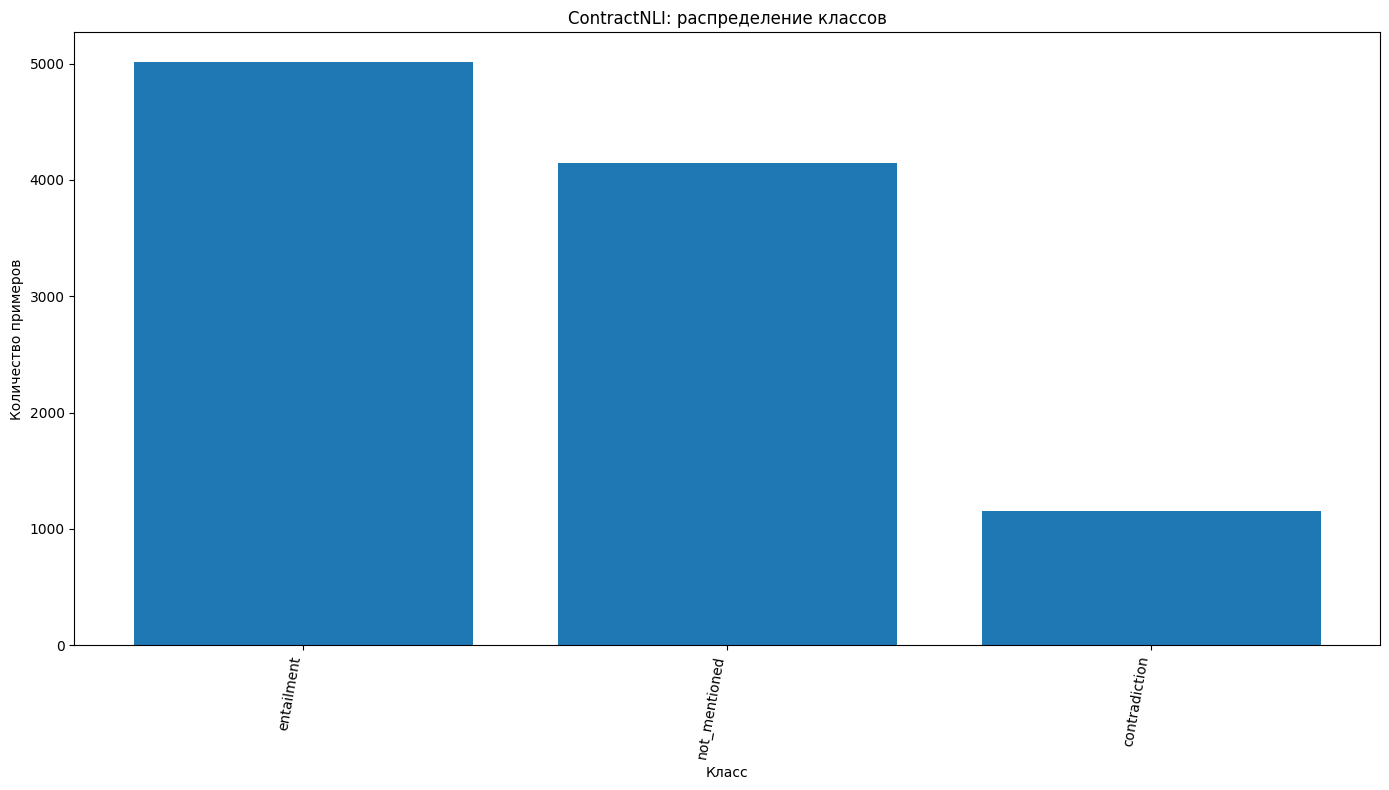

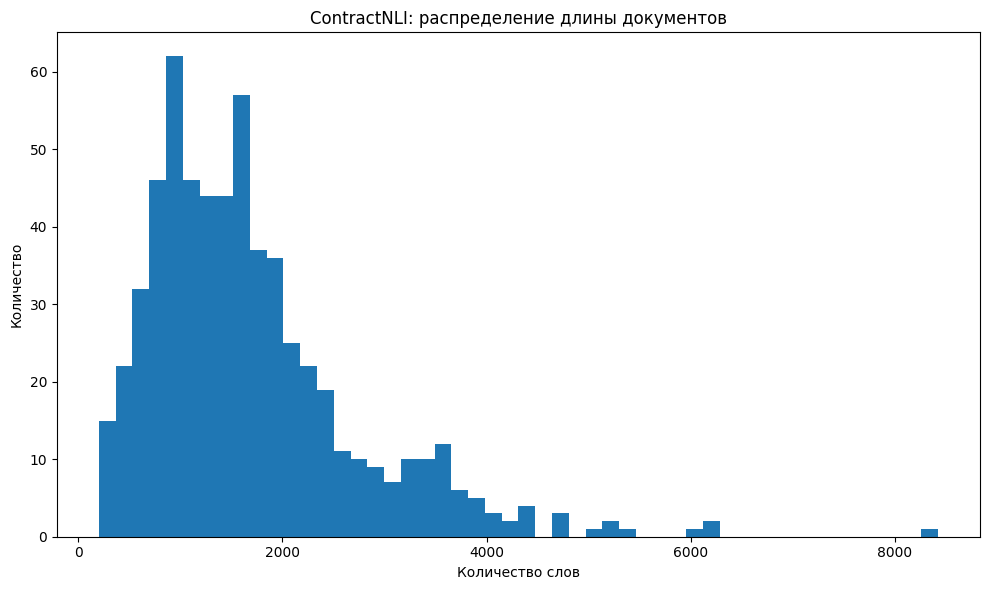

,split,docs,mean_words,median_words,p95_words,max_words,mean_approx_tokens,p95_approx_tokens
0,dev,61,1819.754098,1720.0,3608.0,4792,3023.868852,5939.0
1,test,123,1704.292683,1411.0,3643.9,6254,2804.682927,6014.8
2,train,423,1670.028369,1504.0,3717.8,8424,2762.434988,5937.9


In [44]:
# Графики ContractNLI

contractnli_label_total = (
    contractnli_examples
    .groupby("gold_label")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

save_bar(
    contractnli_label_total,
    "gold_label",
    "count",
    "ContractNLI: распределение классов",
    "Класс",
    "Количество примеров",
    FIGURES_DIR / "contractnli_label_distribution.png",
)

save_hist(
    contractnli_docs["words"],
    "ContractNLI: распределение длины документов",
    "Количество слов",
    FIGURES_DIR / "contractnli_document_words_hist.png",
    bins=50,
)

contractnli_doc_length_by_split = (
    contractnli_docs
    .groupby("split")
    .agg(
        docs=("doc_id", "count"),
        mean_words=("words", "mean"),
        median_words=("words", "median"),
        p95_words=("words", lambda s: float(s.quantile(0.95))),
        max_words=("words", "max"),
        mean_approx_tokens=("approx_tokens", "mean"),
        p95_approx_tokens=("approx_tokens", lambda s: float(s.quantile(0.95))),
    )
    .reset_index()
)

display(contractnli_doc_length_by_split)

contractnli_doc_length_by_split.to_csv(
    EDA_DIR / "contractnli_doc_length_by_split.csv",
    index=False,
)

Evidence spans: (11973, 12)


,split,doc_id,file_name,label_id,gold_label,evidence_index,start,end,length_chars,relative_start,relative_end,text_preview
0,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,nda-16,entailment,0,5021,5179,158,0.584925,0.603332,5. All Confidential Information in any form an...
1,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,nda-16,entailment,1,5179,5347,168,0.603332,0.622903,(a) if a business relationship is not entered ...
2,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,nda-15,entailment,0,4834,5020,186,0.563141,0.584809,4. Nothing in this Agreement is to be construe...
3,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,nda-10,entailment,0,7292,7645,353,0.849487,0.890610,11. The Recipient shall not advertise or other...
4,train,34,Annex E_Non-Disclosure and Confidentiality Agr...,nda-1,entailment,0,1294,1683,389,0.150746,0.196062,"1. “Confidential Information”, whenever used i..."


,gold_label,spans,mean_length_chars,median_length_chars,p95_length_chars,mean_relative_start,median_relative_start
0,contradiction,2192,292.335310,224.0,841.0,0.287815,0.222238
1,entailment,9781,244.414375,192.0,625.0,0.382448,0.350204


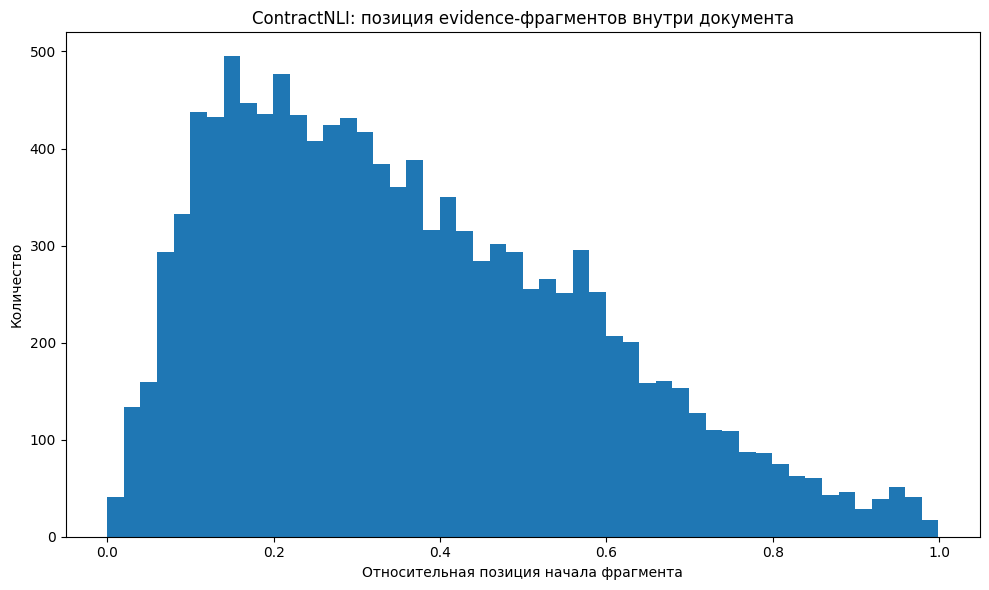

In [45]:
# Evidence-фрагменты ContractNLI как отдельная таблица

evidence_rows = []

doc_length_lookup = (
    contractnli_docs
    .set_index(["split", "doc_id"])["chars"]
    .to_dict()
)

for row in contractnli_examples.itertuples(index=False):
    evidence_items = getattr(row, "evidence", [])

    if not isinstance(evidence_items, list):
        continue

    doc_chars = doc_length_lookup.get((row.split, row.doc_id))

    for evidence_index, evidence_item in enumerate(evidence_items):
        if not isinstance(evidence_item, dict):
            continue

        start = evidence_item.get("start")
        end = evidence_item.get("end")

        if start is None or end is None:
            continue

        start = int(start)
        end = int(end)
        length = max(0, end - start)

        evidence_rows.append(
            {
                "split": row.split,
                "doc_id": row.doc_id,
                "file_name": row.file_name,
                "label_id": row.label_id,
                "gold_label": row.gold_label,
                "evidence_index": evidence_index,
                "start": start,
                "end": end,
                "length_chars": length,
                "relative_start": start / doc_chars if doc_chars else None,
                "relative_end": end / doc_chars if doc_chars else None,
                "text_preview": str(evidence_item.get("text", ""))[:300],
            }
        )

contractnli_evidence_spans = pd.DataFrame(evidence_rows)

print("Evidence spans:", contractnli_evidence_spans.shape)
display(contractnli_evidence_spans.head())

contractnli_evidence_spans.to_csv(
    EDA_DIR / "contractnli_evidence_spans.csv",
    index=False,
)

if len(contractnli_evidence_spans):
    evidence_span_stats = (
        contractnli_evidence_spans
        .groupby("gold_label")
        .agg(
            spans=("length_chars", "size"),
            mean_length_chars=("length_chars", "mean"),
            median_length_chars=("length_chars", "median"),
            p95_length_chars=("length_chars", lambda s: float(s.quantile(0.95))),
            mean_relative_start=("relative_start", "mean"),
            median_relative_start=("relative_start", "median"),
        )
        .reset_index()
    )

    display(evidence_span_stats)

    evidence_span_stats.to_csv(
        EDA_DIR / "contractnli_evidence_span_stats.csv",
        index=False,
    )

    save_hist(
        contractnli_evidence_spans["relative_start"],
        "ContractNLI: позиция evidence-фрагментов внутри документа",
        "Относительная позиция начала фрагмента",
        FIGURES_DIR / "contractnli_evidence_relative_position.png",
        bins=50,
    )
else:
    evidence_span_stats = pd.DataFrame()
    print("Нет распарсенных evidence-фрагментов")

## 6. EDA CUAD: исправленная логика

In [46]:
def is_answer_column(column: str) -> bool:
    return bool(ANSWER_COLUMN_RE.search(column.strip()))


def strip_answer_suffix(column: str) -> str:
    return ANSWER_COLUMN_RE.sub("", column.strip()).strip()


service_columns = set()
if document_col is not None:
    service_columns.add(document_col)

# Эти поля полезны как metadata, но не как clause/evidence extraction.
cuad_metadata_columns = {
    col for col in [
        "Parties",
        "Agreement Date",
        "Effective Date",
        "Expiration Date",
    ]
    if col in cuad_master.columns
}

cuad_answer_columns = [
    col for col in cuad_master.columns
    if col not in service_columns and is_answer_column(col)
]

cuad_text_clause_columns = [
    col for col in cuad_master.columns
    if col not in service_columns
    and col not in cuad_metadata_columns
    and not is_answer_column(col)
]

print("Служебные колонки:", len(service_columns), sorted(service_columns))
print("Metadata-колонки:", len(cuad_metadata_columns), sorted(cuad_metadata_columns))
print("Answer-поля:", len(cuad_answer_columns))
print("Текстовые clause/evidence-поля:", len(cuad_text_clause_columns))


Служебные колонки: 1 ['Filename']
Metadata-колонки: 4 ['Agreement Date', 'Effective Date', 'Expiration Date', 'Parties']
Answer-поля: 41
Текстовые clause/evidence-поля: 37


In [47]:
def parse_cuad_cell_to_texts(value: Any) -> list[str]:
    """
    CUAD master_clauses.csv часто хранит текстовые фрагменты как строковое представление списка:
    "['clause text']".

    Старый код искал в договоре всю строку вместе со скобками и кавычками, поэтому match_rate был 0.
    Здесь мы сначала разбираем список, затем ищем каждый clause-фрагмент отдельно.
    """
    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, list | tuple | set):
        result = [normalize_text(str(item)) for item in value if is_non_empty(item)]
        return [item for item in result if item]

    text = str(value).strip()

    if text in EMPTY_STRINGS:
        return []

    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            parsed = None

        if isinstance(parsed, list | tuple | set):
            result = [normalize_text(str(item)) for item in parsed if is_non_empty(item)]
            return [item for item in result if item]

        if isinstance(parsed, str) and is_non_empty(parsed):
            return [normalize_text(parsed)]

    return [normalize_text(text)]


def normalize_answer_value(value: Any) -> str | None:
    if not is_non_empty(value):
        return None

    text = str(value).strip().lower()

    if text in {"yes", "y", "true", "1"}:
        return "yes"
    if text in {"no", "n", "false", "0"}:
        return "no"

    return text


In [48]:
# CUAD: статистика только по текстовым clause/evidence-полям

cuad_text_clause_stats_rows = []

for col in cuad_text_clause_columns:
    parsed_cells = cuad_master[col].map(parse_cuad_cell_to_texts)
    doc_non_empty_mask = parsed_cells.map(lambda items: len(items) > 0)

    span_texts = [item for items in parsed_cells for item in items]
    span_lengths_chars = pd.Series([len(item) for item in span_texts], dtype="float64")
    span_lengths_words = pd.Series([count_words(item) for item in span_texts], dtype="float64")

    cuad_text_clause_stats_rows.append(
        {
            "clause_column": col,
            "documents_with_text": int(doc_non_empty_mask.sum()),
            "documents_with_text_share": float(doc_non_empty_mask.mean()),
            "span_count": int(len(span_texts)),
            "mean_text_chars": float(span_lengths_chars.mean()) if len(span_lengths_chars) else 0.0,
            "median_text_chars": float(span_lengths_chars.median()) if len(span_lengths_chars) else 0.0,
            "mean_text_words": float(span_lengths_words.mean()) if len(span_lengths_words) else 0.0,
            "median_text_words": float(span_lengths_words.median()) if len(span_lengths_words) else 0.0,
        }
    )

cuad_text_clause_stats = (
    pd.DataFrame(cuad_text_clause_stats_rows)
    .sort_values(["documents_with_text", "span_count", "clause_column"], ascending=[False, False, True])
)

display(cuad_text_clause_stats.head(40))

cuad_text_clause_stats.to_csv(
    EDA_DIR / "cuad_text_clause_stats.csv",
    index=False,
)

,clause_column,documents_with_text,documents_with_text_share,span_count,mean_text_chars,median_text_chars,mean_text_words,median_text_words
0,Document Name,510,1.000000,521,29.190019,25.0,3.280230,3.0
3,Governing Law,437,0.856863,457,206.413567,174.0,34.137856,29.0
14,Anti-Assignment,374,0.733333,612,309.697712,226.5,50.130719,37.0
31,Cap On Liability,275,0.539216,632,392.979430,330.0,62.405063,52.0
21,License Grant,255,0.500000,716,460.750000,372.0,69.699721,57.0
29,Audit Rights,214,0.419608,613,318.794454,260.0,50.003263,41.0
11,Termination For Convenience,183,0.358824,223,242.713004,183.0,39.542601,31.0
28,Post-Termination Services,182,0.356863,409,485.997555,385.0,76.872861,60.0
7,Exclusivity,180,0.352941,388,377.399485,305.0,58.494845,47.5
1,Renewal Term,176,0.345098,199,329.854271,277.0,54.040201,46.0


In [49]:
# CUAD: статистика по Answer-полям как по классификационным меткам

cuad_answer_stats_rows = []

for col in cuad_answer_columns:
    base_clause = strip_answer_suffix(col)
    values = cuad_master[col].map(normalize_answer_value)

    yes_count = int((values == "yes").sum())
    no_count = int((values == "no").sum())
    non_empty_count = int(values.notna().sum())

    cuad_answer_stats_rows.append(
        {
            "answer_column": col,
            "base_clause": base_clause,
            "non_empty_count": non_empty_count,
            "yes_count": yes_count,
            "no_count": no_count,
            "yes_share": yes_count / len(values) if len(values) else 0.0,
            "no_share": no_count / len(values) if len(values) else 0.0,
            "other_count": int(non_empty_count - yes_count - no_count),
        }
    )

cuad_answer_stats = (
    pd.DataFrame(cuad_answer_stats_rows)
    .sort_values(["yes_count", "answer_column"], ascending=[False, True])
)

display(cuad_answer_stats.head(40))

cuad_answer_stats.to_csv(
    EDA_DIR / "cuad_answer_stats.csv",
    index=False,
)

,answer_column,base_clause,non_empty_count,yes_count,no_count,yes_share,no_share,other_count
18,Anti-Assignment-Answer,Anti-Assignment,510,374,136,0.733333,0.266667,0
35,Cap On Liability-Answer,Cap On Liability,510,275,235,0.539216,0.460784,0
25,License Grant-Answer,License Grant,510,255,255,0.500000,0.500000,0
33,Audit Rights-Answer,Audit Rights,510,214,296,0.419608,0.580392,0
15,Termination For Convenience-Answer,Termination For Convenience,510,183,327,0.358824,0.641176,0
32,Post-Termination Services-Answer,Post-Termination Services,510,182,328,0.356863,0.643137,0
11,Exclusivity-Answer,Exclusivity,510,180,330,0.352941,0.647059,0
38,Insurance-Answer,Insurance,510,167,343,0.327451,0.672549,0
19,Revenue/Profit Sharing-Answer,Revenue/Profit Sharing,510,166,344,0.325490,0.674510,0
21,Minimum Commitment-Answer,Minimum Commitment,510,165,345,0.323529,0.676471,0


In [50]:
# CUAD: согласованность Answer-полей и текстовых clause/evidence-полей

answer_column_by_base_clause = {
    strip_answer_suffix(col): col
    for col in cuad_answer_columns
}

cuad_clause_pair_stats_rows = []

for text_col in cuad_text_clause_columns:
    answer_col = answer_column_by_base_clause.get(text_col)

    parsed_cells = cuad_master[text_col].map(parse_cuad_cell_to_texts)
    text_present = parsed_cells.map(lambda items: len(items) > 0)

    if answer_col is not None:
        answer_values = cuad_master[answer_col].map(normalize_answer_value)
        yes_mask = answer_values == "yes"
        no_mask = answer_values == "no"

        yes_count = int(yes_mask.sum())
        no_count = int(no_mask.sum())
        text_when_yes = int((text_present & yes_mask).sum())
        yes_without_text = int((yes_mask & ~text_present).sum())
        text_without_yes = int((text_present & ~yes_mask).sum())
    else:
        yes_count = None
        no_count = None
        text_when_yes = None
        yes_without_text = None
        text_without_yes = None

    cuad_clause_pair_stats_rows.append(
        {
            "clause": text_col,
            "text_column": text_col,
            "answer_column": answer_col,
            "documents_with_text": int(text_present.sum()),
            "documents_with_text_share": float(text_present.mean()),
            "answer_yes_count": yes_count,
            "answer_no_count": no_count,
            "text_when_answer_yes": text_when_yes,
            "answer_yes_without_text": yes_without_text,
            "text_without_answer_yes": text_without_yes,
        }
    )

cuad_clause_pair_stats = (
    pd.DataFrame(cuad_clause_pair_stats_rows)
    .sort_values(["documents_with_text", "clause"], ascending=[False, True])
)

display(cuad_clause_pair_stats.head(40))

cuad_clause_pair_stats.to_csv(
    EDA_DIR / "cuad_clause_pair_stats.csv",
    index=False,
)

,clause,text_column,answer_column,documents_with_text,documents_with_text_share,answer_yes_count,answer_no_count,text_when_answer_yes,answer_yes_without_text,text_without_answer_yes
0,Document Name,Document Name,Document Name-Answer,510,1.000000,0,0,0,0,510
3,Governing Law,Governing Law,Governing Law-Answer,437,0.856863,0,0,0,0,437
14,Anti-Assignment,Anti-Assignment,Anti-Assignment-Answer,374,0.733333,374,136,374,0,0
31,Cap On Liability,Cap On Liability,Cap On Liability-Answer,275,0.539216,275,235,275,0,0
21,License Grant,License Grant,License Grant-Answer,255,0.500000,255,255,255,0,0
29,Audit Rights,Audit Rights,Audit Rights-Answer,214,0.419608,214,296,214,0,0
11,Termination For Convenience,Termination For Convenience,Termination For Convenience-Answer,183,0.358824,183,327,183,0,0
28,Post-Termination Services,Post-Termination Services,Post-Termination Services-Answer,182,0.356863,182,328,182,0,0
7,Exclusivity,Exclusivity,Exclusivity-Answer,180,0.352941,180,330,180,0,0
1,Renewal Term,Renewal Term,Renewal Term-Answer,176,0.345098,0,0,0,0,176


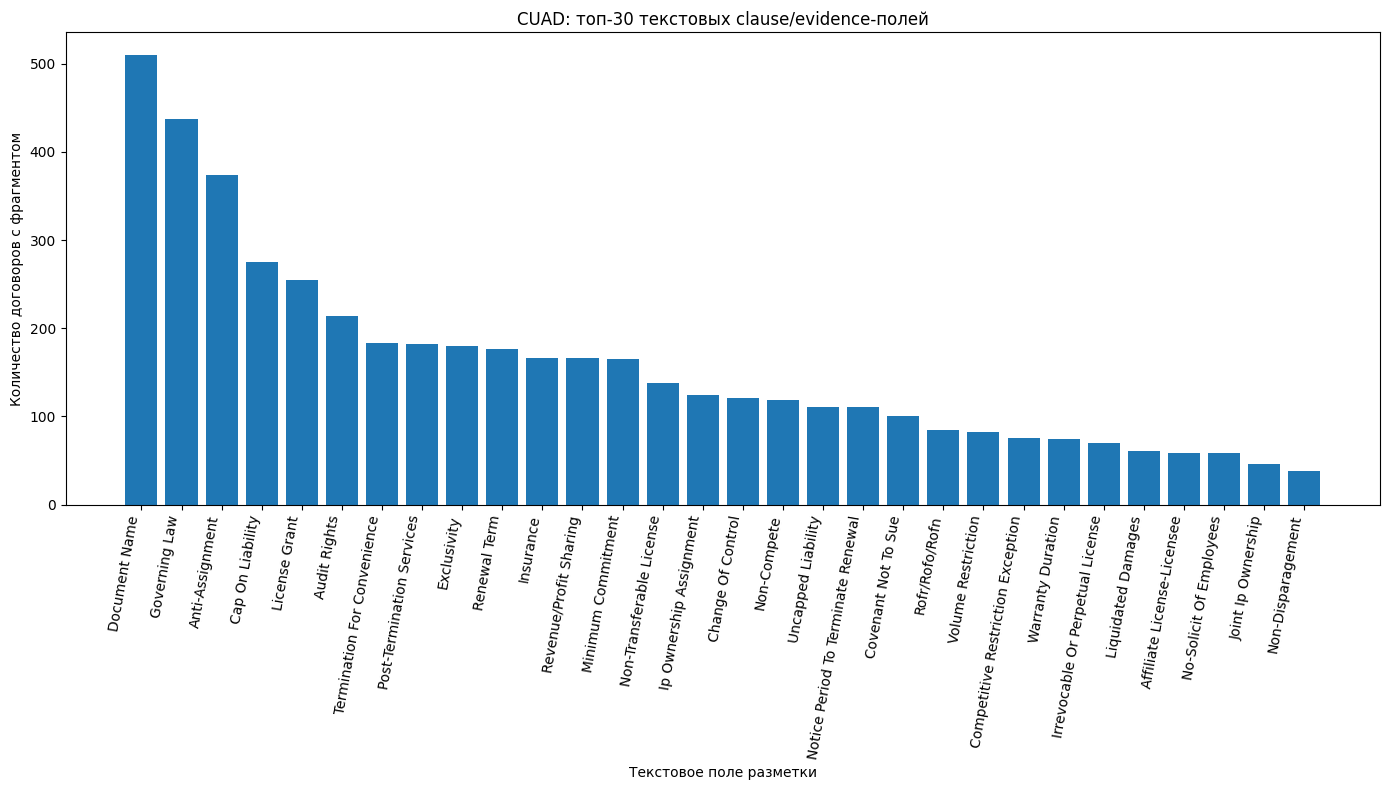

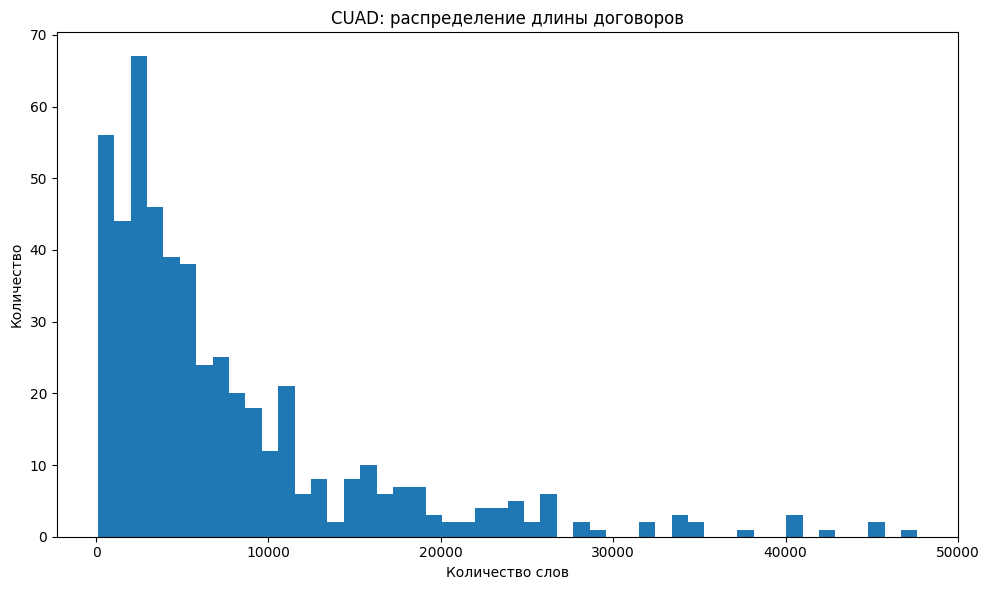

In [51]:
# CUAD: графики по текстовым clause/evidence-полям, а не по Answer-полям

cuad_top_text_clause_stats = cuad_text_clause_stats.head(30)

save_bar(
    cuad_top_text_clause_stats,
    "clause_column",
    "documents_with_text",
    "CUAD: топ-30 текстовых clause/evidence-полей",
    "Текстовое поле разметки",
    "Количество договоров с фрагментом",
    FIGURES_DIR / "cuad_top_text_clause_columns.png",
)

save_hist(
    cuad_docs["words"],
    "CUAD: распределение длины договоров",
    "Количество слов",
    FIGURES_DIR / "cuad_document_words_hist.png",
    bins=50,
)

,count,mean,std,min,25%,50%,75%,max
non_empty_text_clause_fields,510.0,9.647059,5.562729,1.000000,5.000000,9.000000,13.000000,28.000000
empty_text_clause_fields,510.0,27.352941,5.562729,9.000000,24.000000,28.000000,32.000000,36.000000
non_empty_text_clause_share,510.0,0.260731,0.150344,0.027027,0.135135,0.243243,0.351351,0.756757


,document,non_empty_text_clause_fields,empty_text_clause_fields,non_empty_text_clause_share
326,ENERGOUSCORP_03_16_2017-EX-10.24-STRATEGIC ALL...,28,9,0.756757
426,"GOOSEHEADINSURANCE,INC_04_02_2018-EX-10.6-Fran...",25,12,0.675676
272,"BERKELEYLIGHTS,INC_06_26_2020-EX-10.12-COLLABO...",25,12,0.675676
311,SoupmanInc_20150814_8-K_EX-10.1_9230148_EX-10....,24,13,0.648649
178,MRSFIELDSORIGINALCOOKIESINC_01_29_1998-EX-10-F...,24,13,0.648649
185,BUFFALOWILDWINGSINC_06_05_1998-EX-10.3-FRANCHI...,23,14,0.621622
97,DigitalCinemaDestinationsCorp_20111220_S-1_EX-...,23,14,0.621622
117,CoherusBiosciencesInc_20200227_10-K_EX-10.29_1...,22,15,0.594595
158,PlayboyEnterprisesInc_20090220_10-QA_EX-10.2_4...,22,15,0.594595
434,CHANGEPOINTCORP_03_08_2000-EX-10.6-LICENSE AND...,21,16,0.567568


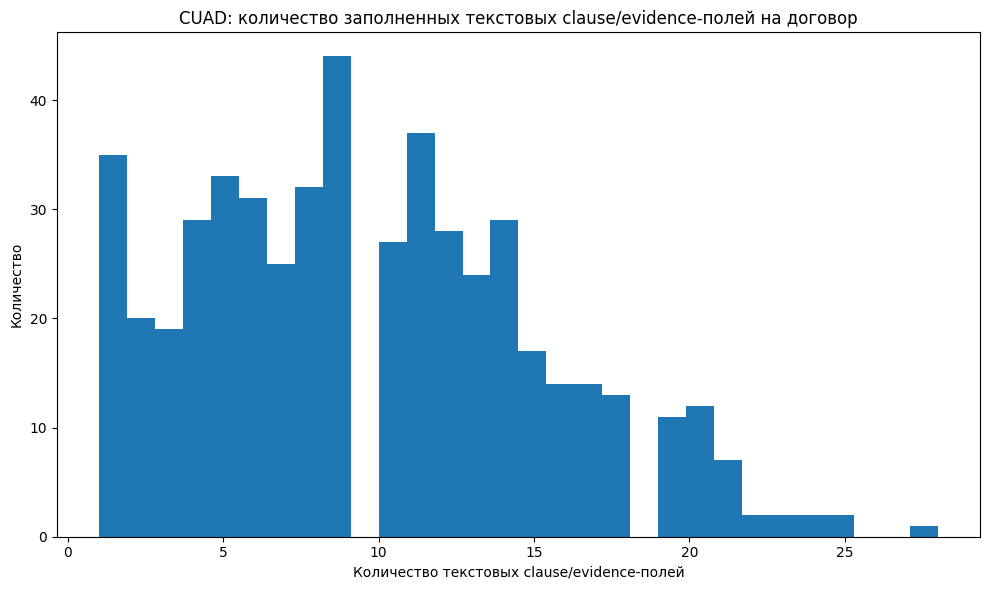

In [52]:
# CUAD: плотность именно текстовой разметки по договору

if document_col is not None:
    text_clause_presence = pd.DataFrame(
        {
            col: cuad_master[col].map(parse_cuad_cell_to_texts).map(lambda items: len(items) > 0)
            for col in cuad_text_clause_columns
        }
    )

    cuad_text_annotation_density = pd.DataFrame(
        {
            "document": cuad_master[document_col].astype(str),
            "non_empty_text_clause_fields": text_clause_presence.sum(axis=1),
            "empty_text_clause_fields": (~text_clause_presence).sum(axis=1),
            "non_empty_text_clause_share": text_clause_presence.mean(axis=1),
        }
    )

    display(cuad_text_annotation_density.describe().T)
    display(
        cuad_text_annotation_density
        .sort_values("non_empty_text_clause_fields", ascending=False)
        .head(20)
    )

    cuad_text_annotation_density.to_csv(
        EDA_DIR / "cuad_text_annotation_density_by_document.csv",
        index=False,
    )

    save_hist(
        cuad_text_annotation_density["non_empty_text_clause_fields"],
        "CUAD: количество заполненных текстовых clause/evidence-полей на договор",
        "Количество текстовых clause/evidence-полей",
        FIGURES_DIR / "cuad_text_annotation_density_hist.png",
        bins=30,
    )
else:
    cuad_text_annotation_density = pd.DataFrame()
    print("document_col не найден, пропускаю плотность текстовой разметки")

In [53]:
# CUAD: кандидаты для MVP только из текстовых clause/evidence-полей

preferred_clause_names = [
    "Governing Law",
    "Anti-Assignment",
    "Cap On Liability",
    "License Grant",
    "Audit Rights",
    "Termination For Convenience",
    "Post-Termination Services",
    "Exclusivity",
    "Renewal Term",
    "Insurance",
    "Revenue/Profit Sharing",
    "Non-Compete",
    "No-Solicit Of Employees",
    "No-Solicit Of Customers",
    "Uncapped Liability",
    "Ip Ownership Assignment",
]

cuad_mvp_preferred_clause_fields = (
    cuad_text_clause_stats[
        cuad_text_clause_stats["clause_column"].isin(preferred_clause_names)
    ]
    .sort_values("documents_with_text", ascending=False)
    .reset_index(drop=True)
)

display(cuad_mvp_preferred_clause_fields)

cuad_mvp_preferred_clause_fields.to_csv(
    EDA_DIR / "cuad_mvp_preferred_clause_fields.csv",
    index=False,
)

,clause_column,documents_with_text,documents_with_text_share,span_count,mean_text_chars,median_text_chars,mean_text_words,median_text_words
0,Governing Law,437,0.856863,457,206.413567,174.0,34.137856,29.0
1,Anti-Assignment,374,0.733333,612,309.697712,226.5,50.130719,37.0
2,Cap On Liability,275,0.539216,632,392.979430,330.0,62.405063,52.0
3,License Grant,255,0.500000,716,460.750000,372.0,69.699721,57.0
4,Audit Rights,214,0.419608,613,318.794454,260.0,50.003263,41.0
5,Termination For Convenience,183,0.358824,223,242.713004,183.0,39.542601,31.0
6,Post-Termination Services,182,0.356863,409,485.997555,385.0,76.872861,60.0
7,Exclusivity,180,0.352941,388,377.399485,305.0,58.494845,47.5
8,Renewal Term,176,0.345098,199,329.854271,277.0,54.040201,46.0
9,Insurance,166,0.325490,531,333.719397,256.0,50.282486,39.0


## CUAD: проверка поиска clause-фрагментов в полном тексте договора

In [54]:
QUOTE_DASH_TRANSLATION = str.maketrans({
    "“": '"',
    "”": '"',
    "„": '"',
    "‟": '"',
    "‘": "'",
    "’": "'",
    "‚": "'",
    "‛": "'",
    "—": "-",
    "–": "-",
    "−": "-",
    "‐": "-",
    "‑": "-",
    "\u00a0": " ",
})


def canonicalize_with_positions(text: str) -> tuple[str, list[int]]:
    """
    Канонизация для поиска с сохранением карты позиций.

    Нужна не для идеальной юридической разметки, а для EDA-проверки:
    можно ли найти CUAD clause-фрагмент в полном TXT-договоре после нормализации пробелов,
    кавычек, тире и регистра.
    """
    chars: list[str] = []
    positions: list[int] = []
    previous_space = True

    for index, raw_char in enumerate(str(text)):
        char = raw_char.translate(QUOTE_DASH_TRANSLATION)

        if char.isspace():
            char = " "
        else:
            char = char.lower()

        if CONTROL_CHARS_RE.match(char):
            continue

        if char == " ":
            if previous_space:
                continue
            previous_space = True
            chars.append(char)
            positions.append(index)
            continue

        previous_space = False
        chars.append(char)
        positions.append(index)

    while chars and chars[-1] == " ":
        chars.pop()
        positions.pop()

    return "".join(chars), positions


def canonicalize_for_search(text: str) -> str:
    return canonicalize_with_positions(text)[0]


def find_clause_span_in_contract(
    contract_text: str,
    contract_canonical: str,
    contract_positions: list[int],
    clause_text: str,
) -> tuple[int | None, int | None, str]:
    clause_text = normalize_text(clause_text)

    if not clause_text:
        return None, None, "empty_clause"

    # Сначала пробуем обычный поиск в нормализованном тексте.
    exact_start = contract_text.find(clause_text)
    if exact_start != -1:
        return exact_start, exact_start + len(clause_text), "exact"

    # Потом пробуем канонический поиск.
    clause_canonical = canonicalize_for_search(clause_text)
    if not clause_canonical:
        return None, None, "empty_canonical_clause"

    canonical_start = contract_canonical.find(clause_canonical)

    if canonical_start == -1:
        return None, None, "not_found"

    canonical_end = canonical_start + len(clause_canonical) - 1

    if canonical_start >= len(contract_positions) or canonical_end >= len(contract_positions):
        return None, None, "position_mapping_error"

    start = contract_positions[canonical_start]
    end = contract_positions[canonical_end] + 1

    return start, end, "canonical"


cuad_contract_text_by_doc_key: dict[str, dict[str, Any]] = {}

for row in cuad_docs.itertuples(index=False):
    doc_key = normalize_doc_key(row.file_stem)
    path = Path(row.path)
    contract_text = normalize_text(path.read_text(encoding="utf-8", errors="replace"))
    contract_canonical, contract_positions = canonicalize_with_positions(contract_text)

    cuad_contract_text_by_doc_key[doc_key] = {
        "text": contract_text,
        "canonical": contract_canonical,
        "positions": contract_positions,
        "path": str(path),
    }

print("CUAD contract text cache:", len(cuad_contract_text_by_doc_key))


CUAD contract text cache: 510


In [55]:
cuad_clause_examples_rows = []

if document_col is None:
    raise ValueError("document_col не найден: невозможно связать CUAD master_clauses.csv с TXT-договорами")

for row_index, row in cuad_master.iterrows():
    document_name = str(row[document_col])
    doc_key = normalize_doc_key(document_name)

    contract_payload = cuad_contract_text_by_doc_key.get(doc_key)
    contract_found = contract_payload is not None

    for clause_col in cuad_text_clause_columns:
        clause_texts = parse_cuad_cell_to_texts(row.get(clause_col))

        for clause_index, clause_text in enumerate(clause_texts):
            if not clause_text:
                continue

            if contract_payload is not None:
                start, end, match_method = find_clause_span_in_contract(
                    contract_payload["text"],
                    contract_payload["canonical"],
                    contract_payload["positions"],
                    clause_text,
                )
            else:
                start, end, match_method = None, None, "contract_not_found"

            cuad_clause_examples_rows.append(
                {
                    "document": document_name,
                    "doc_key": doc_key,
                    "row_index": row_index,
                    "clause_type": clause_col,
                    "clause_index": clause_index,
                    "clause_text": clause_text,
                    "clause_words": count_words(clause_text),
                    "matched_in_contract": start is not None,
                    "match_method": match_method,
                    "start": start,
                    "end": end,
                    "contract_found": contract_found,
                }
            )

cuad_clause_examples = pd.DataFrame(cuad_clause_examples_rows)

print("CUAD clause text examples:", cuad_clause_examples.shape)
display(cuad_clause_examples.head())

print("Match counts:")
display(cuad_clause_examples["matched_in_contract"].value_counts(dropna=False))

print("Match method counts:")
display(cuad_clause_examples["match_method"].value_counts(dropna=False))

cuad_clause_examples.to_csv(
    EDA_DIR / "cuad_clause_examples_match.csv",
    index=False,
)

CUAD clause text examples: (9204, 12)


,document,doc_key,row_index,clause_type,clause_index,clause_text,clause_words,matched_in_contract,match_method,start,end,contract_found
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,cybergyholdingsinc_20140520_10-q_ex-10.27_8605...,0,Document Name,0,MARKETING AFFILIATE AGREEMENT,3,True,exact,15.0,44.0,True
1,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,cybergyholdingsinc_20140520_10-q_ex-10.27_8605...,0,Renewal Term,0,This agreement shall begin upon the date of it...,59,True,exact,1410.0,1780.0,True
2,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,cybergyholdingsinc_20140520_10-q_ex-10.27_8605...,0,Notice Period To Terminate Renewal,0,This Agreement may be terminated by either par...,28,True,exact,22028.0,22183.0,True
3,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,cybergyholdingsinc_20140520_10-q_ex-10.27_8605...,0,Governing Law,0,This Agreement is accepted by Company in the S...,34,True,exact,28654.0,28845.0,True
4,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,cybergyholdingsinc_20140520_10-q_ex-10.27_8605...,0,Non-Disparagement,0,Company shall not specify the business practic...,51,False,not_found,NaN,NaN,True


Match counts:


matched_in_contract
True     8281
False     923
Name: count, dtype: int64

Match method counts:


match_method
exact                 8281
not_found              609
contract_not_found     314
Name: count, dtype: int64

In [56]:
cuad_clause_match_stats = (
    cuad_clause_examples
    .groupby("clause_type")
    .agg(
        examples=("clause_type", "size"),
        matched=("matched_in_contract", "sum"),
        match_rate=("matched_in_contract", "mean"),
        contract_found_rate=("contract_found", "mean"),
        median_clause_words=("clause_words", "median"),
    )
    .reset_index()
    .sort_values(["examples", "clause_type"], ascending=[False, True])
)

display(cuad_clause_match_stats.head(40))

cuad_clause_match_stats.to_csv(
    EDA_DIR / "cuad_clause_match_stats.csv",
    index=False,
)

overall_match_rate = float(cuad_clause_examples["matched_in_contract"].mean()) if len(cuad_clause_examples) else 0.0
print("Overall CUAD clause match rate:", overall_match_rate)

if overall_match_rate < 0.5:
    print(
        "ВНИМАНИЕ: match_rate ниже 0.5. Это не обязательно ошибка EDA, но значит, что для CUAD "
        "нужен более мягкий matching или использование CUAD_v1.json/SQuAD-разметки для координат."
    )

,clause_type,examples,matched,match_rate,contract_found_rate,median_clause_words
15,License Grant,716,640,0.893855,0.970670,57.0
4,Cap On Liability,632,574,0.908228,0.966772,52.0
3,Audit Rights,613,562,0.916803,0.959217,41.0
2,Anti-Assignment,612,557,0.910131,0.970588,37.0
11,Insurance,531,485,0.913371,0.967985,39.0
8,Document Name,521,507,0.973129,0.973129,3.0
10,Governing Law,457,439,0.960613,0.975930,29.0
25,Post-Termination Services,409,350,0.855746,0.941320,60.0
28,Revenue/Profit Sharing,395,361,0.913924,0.972152,45.0
17,Minimum Commitment,392,355,0.905612,0.984694,45.0


Overall CUAD clause match rate: 0.8997175141242938
